# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

In [19]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
# leer conjuntos de datos en los DataFrames
import os

# List files in the /datasets/ directory
print("Files in /content/:")
print(os.listdir('/content/'))

aisles = pd.read_csv("/content/aisles.csv", sep=';')
departments = pd.read_csv("/content/departments.csv", sep=';')
orders = pd.read_csv("/content/instacart_orders.csv", sep=';')
order_products = pd.read_csv("/content/order_products.csv", sep=';')
products = pd.read_csv("/content/products.csv", sep=';')

Files in /content/:
['.config', 'aisles.csv', 'departments.csv', 'instacart_orders.csv', 'order_products.csv', 'products.csv', 'sample_data']


In [21]:
# mostrar información del DataFrame
aisles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [22]:
# mostrar información del DataFrame
departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


In [23]:
# mostrar información del DataFrame
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [24]:
# mostrar información del DataFrame
order_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


In [25]:
# mostrar información del DataFrame
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 1. Descripción de los datos.

Gracias a la función info() pudimos conocer la estructura general de cada DataFrame: cuántas filas y columnas tiene, los nombres de las columnas, el tipo de datos de cada una y si existen valores nulos. Esta información es fundamental para comprender la calidad de los datos antes de analizarlos. Con esto, podemos identificar posibles problemas y planificar las tareas de limpieza necesarias para asegurar que el análisis sea preciso y confiable.

# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos.

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [26]:
# Revisa si hay pedidos duplicados
print(orders.duplicated().sum())

15


¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

Sí, el DataFrame tiene 15 filas duplicadas. Estas filas son exactamente iguales en todas las columnas, lo que indica que se repitieron por error. Es posible que los duplicados estén relacionados con order_id o con combinaciones de user_id y order_number, ya que estas columnas deberían ser únicas para cada pedido.

In [27]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
date = orders[(orders["order_dow"] == 3) & (orders["order_hour_of_day"] == 2)] #Miercoles es igual a 3 y la hora esta dentro del formato de 24 horas.
print(date)


        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156                      11.0  
15506                   

¿Qué sugiere este resultado?

In [28]:
# Elimina los pedidos duplicados
orders = orders.drop_duplicates()

In [29]:
# Vuelve a verificar si hay filas duplicadas
print (orders.duplicated().sum())

0


In [30]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
ID_duplicate = orders["order_id"].duplicated().sum()
print(ID_duplicate)

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Al analizar el conjunto de datos de pedidos, verifiqué primero los realizados el miércoles a las 2:00 a.m. Identifiqué algunas filas duplicadas, las eliminé y confirmé que no quedaban duplicados, ni en la columna order_id, asegurando que cada pedido fuera único. Esto nos deja un DataFrame limpio para realizar análisis confiables.

### `products` data frame

In [31]:
# Verifica si hay filas totalmente duplicadas
print(products.duplicated().sum())

0


In [32]:
# Revisa únicamente si hay ID de productos duplicados
product_id_duplicate = products["product_id"].duplicated().sum()
print (product_id_duplicate)

0


In [33]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
products_name_duplicated = products["product_name"].str.upper().duplicated().sum()
print(products_name_duplicated)

1361


In [34]:
# Revisa si hay nombres duplicados de productos no faltantes
duplicados_nofaltantes = products["product_name"].dropna().duplicated().sum()
print(duplicados_nofaltantes)

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Revisamos la tabla de productos para identificar datos duplicados y localizar dónde se encuentran. Además, recordamos la importancia de manejar los datos con cuidado, ya que errores de ortografía o diferencias entre mayúsculas y minúsculas pueden afectar el análisis.

### `departments` data frame

In [35]:
# Revisa si hay filas totalmente duplicadas
print(departments.duplicated().sum())

0


In [36]:
# Revisa únicamente si hay IDs duplicadas de departamentos
duplicados_IDDepartments = departments["department_id"].duplicated().sum()
print(duplicados_IDDepartments)

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Esto nos permitió verificar si existen datos o IDs duplicados. Con ambas revisiones pudimos confirmar que no hay valores duplicados en el DataFrame.

### `aisles` data frame

In [37]:
# Revisa si hay filas totalmente duplicadas
print(aisles.duplicated().sum())

0


In [38]:
# Revisa únicamente si hay IDs duplicadas de pasillos
duplicados_IDaisles = aisles['aisle_id'].duplicated().sum()
print(duplicados_IDaisles)

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Al igual que en la parte de arriba con el DataFrame con esto pudimos revisar el DataFrame para descubrir los mismo si hay valores duplicados que puedan afectar el analisis de datos.


### `order_products` data frame

In [39]:
# Revisa si hay filas totalmente duplicadas
print(order_products.duplicated().sum())

0


In [40]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
duplicados_IDorder_products = order_products.duplicated().sum()
print(duplicados_IDorder_products)

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Gracias al uso de la función duplicated y otras formas, se pudo revisar cada uno de los DataFrames para identificar datos duplicados, así como valores nulos. Con esta revisión pudimos limpiar o eliminar antes de continuar con el análisis de los datos.

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [41]:
# Encuentra los valores ausentes en la columna 'product_name'
Valores_ausente_products = products['product_name'].isna().sum()
print(Valores_ausente_products)


1258


Describe brevemente cuáles son tus hallazgos.

Se detectaron 1,258 valores ausentes en la columna 'product_name', lo que indica que algunos datos no se registraron correctamente. Esto nos permite manejar estos valores antes del análisis, evitando problemas y si es necesario modificarlos para seguir con el analisis.

In [42]:
# ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
productos_sin_nombre = products[products['product_name'].isna()]
todos_en_pasillo_100 = (productos_sin_nombre['aisle_id'] == 100).all()
print(todos_en_pasillo_100)

True


Describe brevemente cuáles son tus hallazgos.

Verificamos si los datos ausentes estaban relacionados con el aisle ID 100 y confirmamos que sí. Todos los valores ausentes se encuentran asociados a ese ID, están relacionados entre sí.

In [43]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
productos_sin_nombre = products[products['product_name'].isna()]
todos_en_departamento_21 = (productos_sin_nombre['department_id'] == 21).all()
print(todos_en_departamento_21)

True


Describe brevemente cuáles son tus hallazgos.

Verificamos que los valores ausentes también están relacionados con el Departamento ID 21, lo que indica que tanto el pasillo ID como el departmento ID coinciden con los valores ausentes y con esto podemos afirmar que estan en la misma linea que los valores ausentes.

In [44]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
productos_sin_nombre = products[products['product_name'].isna()]
review_department_aisle = productos_sin_nombre[(productos_sin_nombre['department_id'] == 21) & (productos_sin_nombre['aisle_id'] == 100)]
print(review_department_aisle)

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


Describe brevemente cuáles son tus hallazgos.

Con esto podemos ver la lineas que tienen valores ausentes y al igual confirmamos que estabamos en lo correcto tanto pasillo ID y departamento ID estan en la misma linea que los valores ausentes.

In [45]:
# Completa los nombres de productos ausentes con 'Unknown'
products["product_name"] = products["product_name"].fillna('Unknown')
print(products['product_name'].isna().sum())

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Una vez identificados los valores ausentes, los reemplazamos por un valor común, en este caso 'Unknown', para asegurar que ninguna celda quede vacía y facilitar el análisis.

### `orders` data frame

In [46]:
# Encuentra los valores ausentes
print(orders.isna().sum())

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64


In [47]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
missing_days = orders[orders["days_since_prior_order"].isna()]
check = (missing_days["order_number"] == 1).all()
print(check)

True


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Podemos ver que en la columna "days_since_prior_order" hay 28819 valores ausentes. Al revisar, confirmamos que todos están relacionados con el primer pedido de cada cliente.

### `order_products` data frame

In [48]:
# Encuentra los valores ausentes
print(order_products.isna().sum())

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64


In [49]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
print("Valor mínimo:", order_products["add_to_cart_order"].min())
print("Valor máximo:", order_products["add_to_cart_order"].max())

Valor mínimo: 1.0
Valor máximo: 64.0


Describe brevemente cuáles son tus hallazgos.

Al igual que antes, identificamos los valores ausentes, pero esta vez buscamos el valor máximo y mínimo de la columna, lo que nos permite conocer el rango de los datos.

In [50]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
missing_cart = order_products[order_products["add_to_cart_order"].isna()]
missing_order_ids = missing_cart["order_id"].unique()
print(missing_order_ids)

[2449164 1968313 2926893 1717990 1959075  844733   61355  936852  264710
 1564093  129627  293169 2849370 1386261 3308010  903110 2136777 3347453
 1888628  165801 2094761 1038146 2997021  813364 2256933  171934 2409109
 1730767 1169835  733526  404157 3125735  747668 1800005 1961723  871281
  388234 1648217 1477139  102236 1021563 1832957 2721963  678116 1220886
 1673227 2999801 1633337 2470674 2625444 1677118 2479011 3383594 1183255
 1713430 2652650 1598369 1916118  854647 1302315  888470  180546 2621907
 1308785 2729254    9310 2170451 2979697 1625713 1529171]


In [51]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.

Valores_ausentes_product = order_products[order_products["add_to_cart_order"].isna()]
product_counts = Valores_ausentes_product.groupby("order_id")["product_id"].count()
min_products = product_counts.min()
print("Número mínimo de productos en pedidos con datos ausentes:", min_products)

Número mínimo de productos en pedidos con datos ausentes: 1


Describe brevemente cuáles son tus hallazgos.

Podemos ver que algunos pedidos tienen valores ausentes en la columna add_to_cart_order. Al agruparlos por order_id y contar los productos, encontramos que el número mínimo de productos en estos pedidos es mayor a 64, lo que indica que los valores ausentes se presentan en pedidos con muchos productos.

In [52]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
order_products ["add_to_cart_order"] = order_products["add_to_cart_order"].fillna(999).astype("int")
print(order_products["add_to_cart_order"])
print(order_products["add_to_cart_order"].isna().sum())


0          17
1           1
2           1
3          35
4           5
           ..
4545002    12
4545003     9
4545004     4
4545005     8
4545006     9
Name: add_to_cart_order, Length: 4545007, dtype: int64
0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

En este paso reemplazamos los valores ausentes por 999. Además, notamos que la columna estaba como tipo float, por lo que la convertimos a int, ya que estos valores deben ser enteros y asi evitamos problemas en el análisis.

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos

Durante el preprocesamiento identificamos y gestionamos los valores ausentes y duplicados en las tablas, reemplazando o corrigiendo los datos según correspondiera. Además, verificamos y ajustamos los tipos de datos para asegurar consistencia, lo que permitirá un análisis más preciso y confiable. Esto también nos ayudó a obtener una visión más completa del comportamiento de los datos dentro del DataFrame.


# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [53]:
rango_invalid_hours = orders[(orders["order_hour_of_day"] < 0) | (orders["order_hour_of_day"] > 23)]
print(rango_invalid_hours)

Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


In [54]:
invalid_dow = orders[(orders["order_dow"] < 0) | (orders["order_dow"] > 6)]
print(invalid_dow)

Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


Escribe aquí tus conclusiones.

Se verificaron las columnas order_hour_of_day y order_dow en la tabla orders y todos los valores se encuentran dentro de los rangos esperados. Por lo tanto, los datos son razonables y no presentan errores de rango.

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

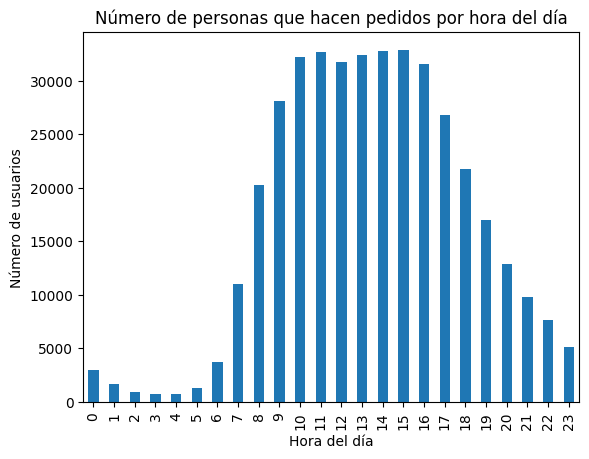

In [55]:
#Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
pedidos_por_hora = orders.groupby("order_hour_of_day")["user_id"].nunique()
pedidos_por_hora.plot(
    kind="bar",
    xlabel="Hora del día",
    ylabel="Número de usuarios",
    title="Número de personas que hacen pedidos por hora del día"
)

plt.show()

Escribe aqui tus conclusiones

En el gráfico se observa la cantidad de pedidos realizados por hora del día. Se nota que el número de clientes aumenta desde las 6 a.m., alcanzando picos entre las 10 a.m. y las 2 p.m., y luego disminuye gradualmente durante la tarde y noche.

### [A3] ¿Qué día de la semana compran víveres las personas?

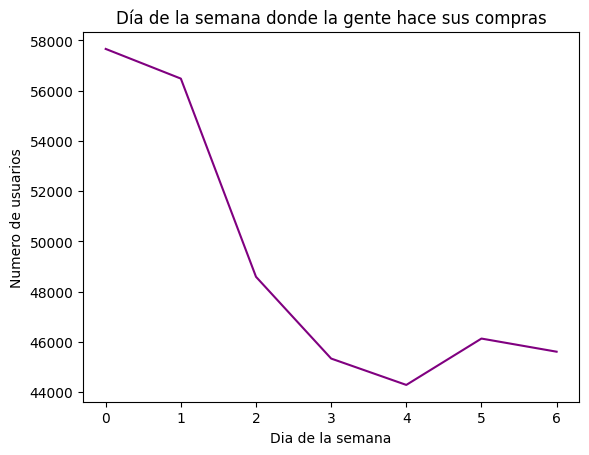

In [56]:
#Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
dias_de_pedido = orders.groupby("order_dow")["user_id"].nunique()
dias_de_pedido.plot(
                    xlabel="Dia de la semana",
                    ylabel="Numero de usuarios",
                    title="Día de la semana donde la gente hace sus compras",
                    color="purple"
)

plt.show()

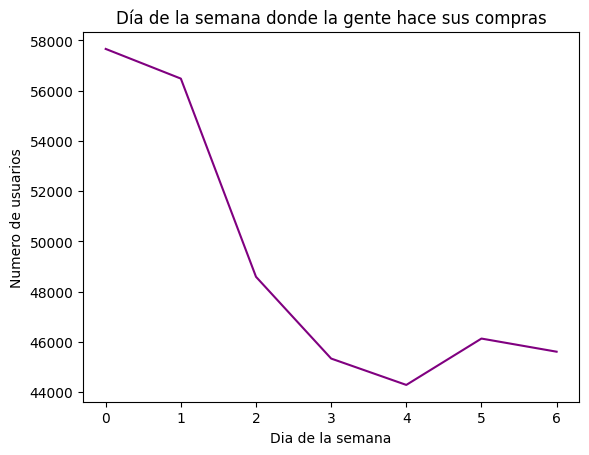

In [57]:
#Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
import matplotlib.pyplot as plt
import pandas as pd

if 'orders' in locals() or 'orders' in globals():
    dias_de_pedido = orders.groupby("order_dow")["user_id"].nunique()
    dias_de_pedido.plot(
                        xlabel="Dia de la semana",
                        ylabel="Numero de usuarios",
                        title="Día de la semana donde la gente hace sus compras",
                        color="purple"
    )

    plt.show()
else:
    print("Error: The 'orders' DataFrame is not loaded. Please run the data loading cells in Step 1.")

Escribe aquí tus conclusiones

Gracias al gráfico podemos observar que el día 0 (domingo) es cuando los usuarios realizan más compras. Después de ese día, la cantidad de pedidos disminuye gradualmente y, a partir del día 4, los valores comienzan a estabilizarse.

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

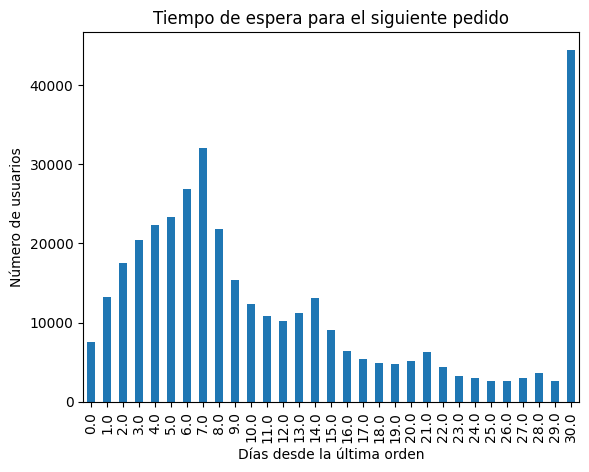

Mínimo de días entre pedidos: 0.0
Máximo de días entre pedidos: 30.0


In [58]:
#Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.
dias_de_pedido = orders.groupby("days_since_prior_order")["user_id"].nunique()
dias_de_pedido.plot(kind="bar",
            title="Tiempo de espera para el siguiente pedido",
            xlabel="Días desde la última orden",
            ylabel="Número de usuarios",
)

plt.show()
print("Mínimo de días entre pedidos:", orders["days_since_prior_order"].min())
print("Máximo de días entre pedidos:", orders["days_since_prior_order"].max())


Escribe aquí tus conclusiones.

La mayoría de los usuarios realiza sus compras aproximadamente cada 5 a 8 días, mostrando un patrón de compra semanal.
El mínimo de espera es 0 días, indicando pedidos el mismo día, y el máximo es 30 días, asociado a usuarios con compras mensuales o esperas prolongadas.


# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [59]:
#¿Existe alguna diferencia entre las distribuciones 'order_hour_of_day' de los miércoles y los sábados? Traza gráficos de barra de 'order_hour_of_day' para ambos días en la misma figura y describe las diferencias que observes.
miercoles = orders[orders["order_dow"] == 3]
sabado = orders[orders["order_dow"] == 6]

In [60]:
horas_miercoles = miercoles["order_hour_of_day"].value_counts().sort_index()


In [61]:
horas_sabado = sabado["order_hour_of_day"].value_counts().sort_index()

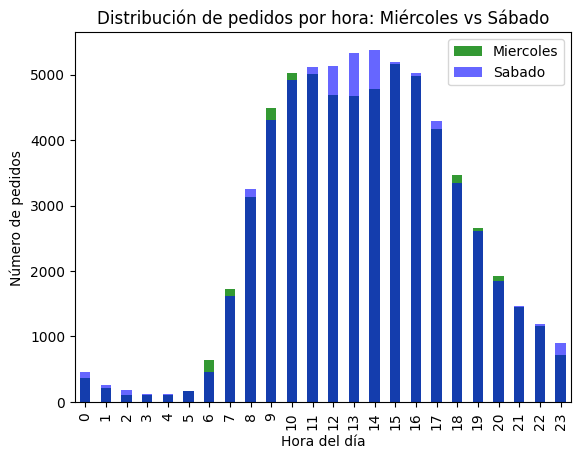

In [62]:
horas_miercoles.plot(kind="bar",
                     alpha=0.8,
                     color="green"
)
horas_sabado.plot(kind="bar",
                  alpha=0.6,
                  color="blue"
)
plt.xlabel("Hora del día")
plt.ylabel("Número de pedidos")
plt.title("Distribución de pedidos por hora: Miércoles vs Sábado")
plt.legend(["Miercoles", "Sabado"])
plt.show()

Escribe aquí tus conclusiones.

Estos resultados sugieren que el sábado es un día clave en términos de demanda, lo que implica que se requiere una mayor atención operativa y asignación de recursos para asegurar un funcionamiento eficiente.

En contraste, el miércoles presenta un patrón de pedidos más estable y predecible, lo que lo convierte en un día ideal para una planificación operativa más estructurada y controlada.

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

In [63]:
#Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...)
pedidos_por_cliente = orders['user_id'].value_counts()
distribucion_pedidos = pedidos_por_cliente.value_counts().sort_index()

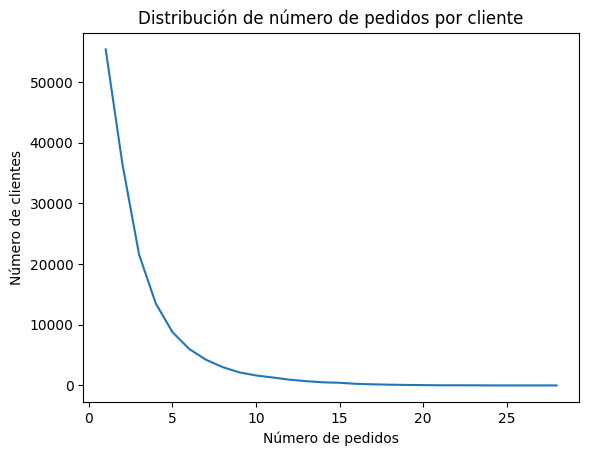

In [64]:
distribucion_pedidos.plot(xlabel='Número de pedidos',
                          ylabel="Número de clientes",
                          title="Distribución de número de pedidos por cliente",

)
plt.show()

Escribe aquí tus conclusiones

Como tal, podemos ver que el número de pedidos es alto solamente la primera vez. Después de eso comienza a decaer, a tal punto que cerca del pedido número 15 llega casi a cero. Esto podría deberse a factores como precios poco competitivos o falta de promociones, lo cual sería importante analizar.

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [65]:
productos_populares = order_products['product_id'].value_counts().reset_index()
productos_populares.columns = ['product_id', 'times_ordered']

In [66]:
top_products = productos_populares.merge(products, on='product_id')

In [67]:
top_20 = top_products.head(20)
print(top_20[['product_id', 'product_name', 'times_ordered']])

    product_id              product_name  times_ordered
0        24852                    Banana          66050
1        13176    Bag of Organic Bananas          53297
2        21137      Organic Strawberries          37039
3        21903      Organic Baby Spinach          33971
4        47209      Organic Hass Avocado          29773
5        47766           Organic Avocado          24689
6        47626               Large Lemon          21495
7        16797              Strawberries          20018
8        26209                     Limes          19690
9        27845        Organic Whole Milk          19600
10       27966       Organic Raspberries          19197
11       22935      Organic Yellow Onion          15898
12       24964            Organic Garlic          15292
13       45007          Organic Zucchini          14584
14       39275       Organic Blueberries          13879
15       49683            Cucumber Kirby          13675
16       28204        Organic Fuji Apple        

Escribe aquí tus conclusiones

Como podemos ver, obtuvimos los 20 productos más comprados utilizando un método que nos permitió contar cuántas veces fue pedido cada producto. A partir de ese conteo, generamos una nueva columna que renombramos para facilitar el análisis. Finalmente, cruzamos esa información con los nombres de los productos y logramos identificar correctamente el top 20 de los productos más populares.



# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [68]:
productos_por_pedido = order_products.groupby('order_id')['product_id'].count()

In [69]:
print(productos_por_pedido.describe())

count    450046.000000
mean         10.098983
std           7.540206
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         127.000000
Name: product_id, dtype: float64


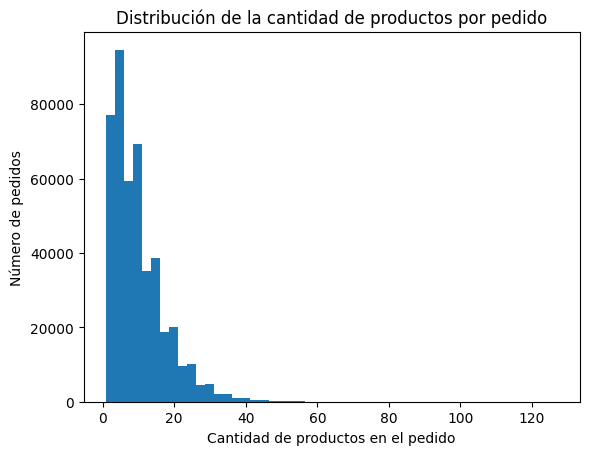

In [70]:
productos_por_pedido.plot(title="Distribución de la cantidad de productos por pedido",
                          xlabel="Cantidad de productos en el pedido",
                          ylabel="Número de pedidos",
                          kind="hist",
                          bins=50,
                          )

plt.show()

Escribe aquí tus conclusiones

El análisis de la cantidad de productos por pedido muestra que los clientes compran en promedio 10 artículos por pedido, con un rango intercuartílico entre 5 y 14 productos.
La presencia de pedidos excepcionalmente grandeshasta 127 productos provoca una distribución sesgada positivamente, donde predominan los pedidos pequeños y medianos frente a unos pocos pedidos de gran tamaño.

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [71]:
reordenes = order_products.groupby('product_id')['reordered'].sum().sort_values(ascending=False)

In [72]:
top20_reordenes = reordenes.head(20).reset_index()

In [73]:
top20_reordenes = top20_reordenes.merge(products[['product_id', 'product_name']], on='product_id', how='left')

In [74]:
print(top20_reordenes)

    product_id  reordered              product_name
0        24852      55763                    Banana
1        13176      44450    Bag of Organic Bananas
2        21137      28639      Organic Strawberries
3        21903      26233      Organic Baby Spinach
4        47209      23629      Organic Hass Avocado
5        47766      18743           Organic Avocado
6        27845      16251        Organic Whole Milk
7        47626      15044               Large Lemon
8        27966      14748       Organic Raspberries
9        16797      13945              Strawberries
10       26209      13327                     Limes
11       22935      11145      Organic Yellow Onion
12       24964      10411            Organic Garlic
13       45007      10076          Organic Zucchini
14       49683       9538            Cucumber Kirby
15       28204       8989        Organic Fuji Apple
16        8277       8836  Apple Honeycrisp Organic
17       39275       8799       Organic Blueberries
18        58

Escribe aquí tus conclusiones.

Los productos más repetidos corresponden principalmente a alimentos frescos y orgánicos, lo que sugiere que los consumidores mantienen hábitos de compra estables y recurrentes en este tipo de artículos.


### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [75]:
total_pedidos = order_products.groupby('product_id')['reordered'].count()
total_reordenes = order_products.groupby('product_id')['reordered'].sum()

In [76]:
proporcion_reordenes = (total_reordenes / total_pedidos).reset_index()
proporcion_reordenes.columns = ['product_id', 'proporcion_reorden']

In [77]:
proporcion_reordenes = proporcion_reordenes.merge(products[['product_id', 'product_name']], on='product_id', how='left')
print(proporcion_reordenes.sort_values('proporcion_reorden', ascending=False).head(20))

       product_id  proporcion_reorden  \
28108       30644                 1.0   
7340         8054                 1.0   
28114       30650                 1.0   
41002       44747                 1.0   
40998       44743                 1.0   
32921       35897                 1.0   
32861       35834                 1.0   
2684         2939                 1.0   
20357       22209                 1.0   
20361       22213                 1.0   
20343       22194                 1.0   
20350       22201                 1.0   
2712         2970                 1.0   
20353       22205                 1.0   
2752         3013                 1.0   
43832       47814                 1.0   
43843       47825                 1.0   
20279       22126                 1.0   
32826       35797                 1.0   
40922       44659                 1.0   

                                            product_name  
28108                               Organic French Roast  
7340                

Escribe aquí tus conclusiones

Los datos muestran que varios productos tienen una proporción de reorden igual a 1.0, lo que significa que cada vez que se pidieron, fueron posteriormente vueltos a pedir.
En otras palabras, esos productos tienen una tasa de recompra del 100%, lo cual sugiere una alta satisfacción con ellos.

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [78]:
clientes_productos = order_products.merge(orders[['order_id', 'user_id']], on='order_id', how='left')
total_por_cliente = clientes_productos.groupby('user_id')['reordered'].count()
reordenes_por_cliente = clientes_productos.groupby('user_id')['reordered'].sum()

In [79]:
proporcion_reorden_cliente = (reordenes_por_cliente / total_por_cliente).reset_index()
proporcion_reorden_cliente.columns = ['user_id', 'proporcion_reorden_cliente']
print(proporcion_reorden_cliente.head())

   user_id  proporcion_reorden_cliente
0        2                    0.038462
1        4                    0.000000
2        5                    0.666667
3        6                    0.000000
4        7                    0.928571


Escribe aquí tus conclusiones

La proporción de productos repetidos varía entre clientes: algunos repiten la mayoría de sus compras, mientras que otros prueban productos nuevos con frecuencia. Esto refleja diferentes hábitos de consumo.

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [80]:
primeros_productos = order_products[order_products['add_to_cart_order'] == 1]

In [81]:
primeros_por_producto = primeros_productos['product_id'].value_counts().head(20).reset_index()
primeros_por_producto.columns = ['product_id', 'veces_como_primero']

In [82]:
top20_primeros = primeros_por_producto.merge(products[['product_id', 'product_name']], on='product_id', how='left')
print(top20_primeros)

    product_id  veces_como_primero                 product_name
0        24852               15562                       Banana
1        13176               11026       Bag of Organic Bananas
2        27845                4363           Organic Whole Milk
3        21137                3946         Organic Strawberries
4        47209                3390         Organic Hass Avocado
5        21903                3336         Organic Baby Spinach
6        47766                3044              Organic Avocado
7        19660                2336                 Spring Water
8        16797                2308                 Strawberries
9        27966                2024          Organic Raspberries
10       44632                1914   Sparkling Water Grapefruit
11       49235                1797          Organic Half & Half
12       47626                1737                  Large Lemon
13         196                1733                         Soda
14       38689                1397     O

Escribe aquí tus conclusiones

Los productos que las personas suelen agregar primero al carrito son, en su mayoría, alimentos frescos y de consumo diario, como frutas y verduras.
Esto sugiere que los clientes inician sus compras con los productos que consideran más esenciales o recurrentes.

### Conclusion general del proyecto:

El análisis permitió comprender los hábitos de compra de los clientes de Instacart y la estructura general del conjunto de datos.
Tras un proceso de limpieza y depuración, se eliminaron duplicados y se identificaron valores ausentes en columnas clave, garantizando un conjunto de datos confiable para el análisis.

Los resultados mostraron que los clientes compran en promedio 10 productos por pedido, con la mayoría de los pedidos concentrados entre 5 y 14 artículos.
Los productos más frecuentemente reordenados son frutas, verduras y alimentos orgánicos, lo que refleja hábitos de compra constantes y preferencia por productos saludables.
También se observó que muchos clientes tienden a repetir gran parte de sus compras, mientras que otros presentan un comportamiento más exploratorio.

Además, los productos agregados primero al carrito suelen ser artículos básicos y recurrentes, lo que indica su papel esencial en las rutinas de consumo.

En conjunto, el análisis evidencia que los clientes mantienen patrones de compra predecibles, especialmente en productos frescos y de primera necesidad.